In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [4]:
df = pd.read_csv('../reference/employee_salary_regression.csv')
df_staging = df.copy()
df_staging.head(5) # atau .tail()

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80
4,EMP0005,24,1,High School,DevOps,1,3.7,12,1,94126.86


In [5]:
df_staging.sample()

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
808,EMP0809,52,28,Bachelor,ML Engineer,1,3.2,9,1,169631.51


In [6]:
df.sort_values('age')

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
944,EMP0945,22,0,High School,Product Manager,2,4.5,8,1,92338.36
963,EMP0964,22,0,High School,Data Analyst,2,2.1,3,0,69835.66
953,EMP0954,22,0,PhD,DevOps,2,4.6,11,0,105181.34
897,EMP0898,22,0,High School,Data Analyst,2,2.9,4,1,72952.94
905,EMP0906,22,0,Master,Software Engineer,3,5.0,11,0,92850.61
...,...,...,...,...,...,...,...,...,...,...
526,EMP0527,60,40,Bachelor,QA Engineer,2,3.3,5,1,196182.46
207,EMP0208,60,38,High School,Data Analyst,1,2.1,12,1,198576.12
144,EMP0145,60,38,High School,Software Engineer,2,4.1,6,1,188949.25
30,EMP0031,60,40,Bachelor,DevOps,1,4.8,11,0,213998.04


In [7]:
df_staging.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        1000 non-null   str    
 1   age                1000 non-null   int64  
 2   years_experience   1000 non-null   int64  
 3   education_level    1000 non-null   str    
 4   job_role           1000 non-null   str    
 5   city_tier          1000 non-null   int64  
 6   performance_score  1000 non-null   float64
 7   num_skills         1000 non-null   int64  
 8   remote_work        1000 non-null   int64  
 9   annual_salary_usd  1000 non-null   float64
dtypes: float64(2), int64(5), str(3)
memory usage: 103.4 KB


In [8]:
df_staging.dtypes

employee_id              str
age                    int64
years_experience       int64
education_level          str
job_role                 str
city_tier              int64
performance_score    float64
num_skills             int64
remote_work            int64
annual_salary_usd    float64
dtype: object

In [9]:
df_staging.columns.tolist()

['employee_id',
 'age',
 'years_experience',
 'education_level',
 'job_role',
 'city_tier',
 'performance_score',
 'num_skills',
 'remote_work',
 'annual_salary_usd']

In [10]:
df_staging.select_dtypes(include='number').columns.tolist()

['age',
 'years_experience',
 'city_tier',
 'performance_score',
 'num_skills',
 'remote_work',
 'annual_salary_usd']

In [11]:
    df_staging.select_dtypes(include='str').columns.tolist()

['employee_id', 'education_level', 'job_role']

In [12]:
df.index

RangeIndex(start=0, stop=1000, step=1)

In [13]:
df.sort_values(['age', 'years_experience'], ascending=[True, False])

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
13,EMP0014,22,2,Master,QA Engineer,2,2.3,8,0,83564.49
387,EMP0388,22,2,PhD,DevOps,3,3.3,4,1,86111.05
266,EMP0267,22,1,Bachelor,QA Engineer,1,4.2,9,0,97709.55
450,EMP0451,22,1,PhD,DevOps,1,2.2,9,1,97406.30
528,EMP0529,22,1,High School,Product Manager,2,3.1,8,1,79108.69
...,...,...,...,...,...,...,...,...,...,...
284,EMP0285,60,36,PhD,Product Manager,1,3.9,9,1,205695.10
463,EMP0464,60,36,Master,QA Engineer,3,4.6,10,0,186346.58
602,EMP0603,60,36,High School,Software Engineer,2,2.9,8,0,178169.85
614,EMP0615,60,36,High School,Software Engineer,1,3.5,9,0,198610.71


In [14]:
df.iloc[0]

employee_id                    EMP0001
age                                 29
years_experience                     9
education_level                 Master
job_role             Software Engineer
city_tier                            1
performance_score                  2.4
num_skills                           3
remote_work                          0
annual_salary_usd            106343.31
Name: 0, dtype: object

In [15]:
df.iloc[:4]

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80


In [16]:
# Audit

def Audit(df):  
    if df.empty:
        return pd.DataFrame()
        
    return pd.DataFrame({
        'dtype'     : df.dtypes,
        'nulls'     : df.isnull().sum(),
        'null_%'    : (df.isnull().mean()*100).round(2),
        'unique'    : df.nunique(),
        'unique_%'  : (df.nunique()/len(df)*100).round(2),
        'zeros'     : (df == 0).sum(),
        'sample'    : df.iloc[0]
    })

Audit(df)

,dtype,nulls,null_%,unique,unique_%,zeros,sample
employee_id,str,0,0.0,1000,100.0,0,EMP0001
age,int64,0,0.0,39,3.9,0,29
years_experience,int64,0,0.0,41,4.1,45,9
education_level,str,0,0.0,4,0.4,0,Master
job_role,str,0,0.0,6,0.6,0,Software Engineer
city_tier,int64,0,0.0,3,0.3,0,1
performance_score,float64,0,0.0,31,3.1,0,2.4
num_skills,int64,0,0.0,11,1.1,0,3
remote_work,int64,0,0.0,2,0.2,512,0
annual_salary_usd,float64,0,0.0,1000,100.0,0,106343.31


In [17]:
df.describe()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.668000,18.617000,2.046000,3.506200,7.161000,0.488000,137295.111970
std,11.536415,11.634848,0.826176,0.863775,3.103661,0.500106,34692.969621
min,22.000000,0.000000,1.000000,2.000000,2.000000,0.000000,66716.640000
25%,30.000000,8.000000,1.000000,2.800000,4.000000,0.000000,107616.092500
50%,41.000000,19.000000,2.000000,3.500000,7.000000,0.000000,137537.955000
75%,51.000000,29.000000,3.000000,4.300000,10.000000,1.000000,164807.105000
max,60.000000,40.000000,3.000000,5.000000,12.000000,1.000000,217067.540000


In [18]:
df.remote_work.value_counts()

# parameter
# normalize=True: Alih-alih mengembalikan jumlah (count), ini mengembalikan persentase/proporsi dari setiap nilai.
# dropna=False: Secara bawaan, Pandas mengabaikan data kosong (NaN). Dengan menset parameter ini ke False, kita bisa melihat berapa banyak data yang kosong.
# ascending=True: Mengurutkan hasil dari yang paling jarang muncul ke yang paling sering (bawaannya adalah dari yang terbanyak).
# bins=n: Sangat berguna untuk data numerik. Parameter ini akan otomatis mengelompokkan angka ke dalam n buah interval (mirip membuat histogram).


remote_work
0    512
1    488
Name: count, dtype: int64

In [19]:
df.education_level.value_counts()

education_level
Bachelor       258
PhD            256
Master         246
High School    240
Name: count, dtype: int64

In [20]:
df_avg_sal = df.copy()
df_avg_sal['avg_salary'] = df_avg_sal.groupby('job_role')['annual_salary_usd'].transform('mean')
df_avg_sal[['job_role', 'annual_salary_usd', 'avg_salary']]


,job_role,annual_salary_usd,avg_salary
0,Software Engineer,106343.31,135378.818816
1,ML Engineer,82852.60,140147.600476
2,Data Analyst,142019.59,135236.799607
3,DevOps,159972.80,140245.784526
4,DevOps,94126.86,140245.784526
...,...,...,...
995,ML Engineer,127579.68,140147.600476
996,Product Manager,96672.53,134972.026131
997,Software Engineer,107247.32,135378.818816
998,DevOps,100412.67,140245.784526


In [21]:
df_staging[['age']].corr(method='pearson')

,age
age,1.0


In [22]:
df_staging.isnull().sum()

employee_id          0
age                  0
years_experience     0
education_level      0
job_role             0
city_tier            0
performance_score    0
num_skills           0
remote_work          0
annual_salary_usd    0
dtype: int64

In [23]:
df_staging.isnull().mean()*100

employee_id          0.0
age                  0.0
years_experience     0.0
education_level      0.0
job_role             0.0
city_tier            0.0
performance_score    0.0
num_skills           0.0
remote_work          0.0
annual_salary_usd    0.0
dtype: float64

In [24]:
# Rows with all NULL
df_staging.isnull().all(axis=1).sum()

np.int64(0)

In [25]:
# Column with missing > threshold
df_staging.columns[df_staging.isnull().mean() > 0.3]


Index([], dtype='str')

In [26]:
df_exp_bracket = df_staging.copy()

bins = [0, 10, 20, 30, 40, 50]  
labels = ['Junior', 'Mid-Level', 'Senior', 'Expert', 'Veteran']

# Gunakan pd.cut untuk membuat kolom baru pada dataset (dataset berubah, untungnya sudah copy)
df_exp_bracket['experience_bracket'] = pd.cut(
    df_exp_bracket['years_experience'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)
df_exp_bracket['experience_bracket']


0         Junior
1         Junior
2      Mid-Level
3         Senior
4         Junior
         ...    
995    Mid-Level
996       Junior
997       Junior
998       Junior
999    Mid-Level
Name: experience_bracket, Length: 1000, dtype: category
Categories (5, str): ['Junior' < 'Mid-Level' < 'Senior' < 'Expert' < 'Veteran']

In [27]:
# pakai if-elif-else untuk merubah nilai pada kolom asli dengan membuat function yang nantinya di .apply pada kolom yang hendak dirubah nilainya. (tidak menambahkan kolom baru seperti pd.cut tapi merubah value pada kolom)
def exp_bracket(years):
    if years < 10:
        return 'Junior'
    elif years < 20:
        return 'Mid-Level'
    elif years < 30:
        return 'Senior'
    elif years < 40:
        return 'Expert'
    else :
        return 'Veteran'

# Terapkan ke kolom
df_exp_bracket['years_experience'] = df_exp_bracket['years_experience'].apply(exp_bracket)
df_exp_bracket['years_experience']

0         Junior
1         Junior
2      Mid-Level
3         Senior
4         Junior
         ...    
995    Mid-Level
996       Junior
997    Mid-Level
998       Junior
999       Senior
Name: years_experience, Length: 1000, dtype: str

In [28]:
# paling aman tanpa perubahan pada dataset df_staging
# df_staging tetap utuh, df_exp_bracket adalah DataFrame baru yang lengkap
df_exp_bracket2 = df_staging.assign(
    experience_bracket = pd.cut(
        df_staging['years_experience'], 
        bins=bins, 
        labels=labels, 
        include_lowest=True
    )
)
df_exp_bracket2

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,experience_bracket
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31,Junior
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60,Junior
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59,Mid-Level
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80,Senior
4,EMP0005,24,1,High School,DevOps,1,3.7,12,1,94126.86,Junior
...,...,...,...,...,...,...,...,...,...,...,...
995,EMP0996,37,13,Master,ML Engineer,2,3.4,11,0,127579.68,Mid-Level
996,EMP0997,27,5,PhD,Product Manager,3,4.5,6,1,96672.53,Junior
997,EMP0998,33,10,Bachelor,Software Engineer,3,4.2,9,1,107247.32,Junior
998,EMP0999,33,9,High School,DevOps,3,4.8,5,0,100412.67,Junior


In [29]:
df_exp_bracket.groupby('job_role')['annual_salary_usd'].mean().sort_values(ascending=False)


job_role
DevOps               140245.784526
ML Engineer          140147.600476
QA Engineer          137707.178545
Software Engineer    135378.818816
Data Analyst         135236.799607
Product Manager      134972.026131
Name: annual_salary_usd, dtype: float64

In [30]:
skill_bins = [0,5,10,12]
skill_labels = ['Intermediate', 'Advanced', 'Expert']
df_exp_skill_bracket = df_exp_bracket.assign( 
    skill_bracket=pd.cut(
        df_exp_bracket['num_skills'],
        bins= skill_bins,
        labels= skill_labels,
        include_lowest=True
    )
)
df_exp_skill_bracket 

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,experience_bracket,skill_bracket
0,EMP0001,29,Junior,Master,Software Engineer,1,2.4,3,0,106343.31,Junior,Intermediate
1,EMP0002,27,Junior,Bachelor,ML Engineer,3,2.1,5,1,82852.60,Junior,Intermediate
2,EMP0003,36,Mid-Level,Master,Data Analyst,1,4.1,7,1,142019.59,Mid-Level,Advanced
3,EMP0004,43,Senior,High School,DevOps,1,3.1,7,1,159972.80,Senior,Advanced
4,EMP0005,24,Junior,High School,DevOps,1,3.7,12,1,94126.86,Junior,Expert
...,...,...,...,...,...,...,...,...,...,...,...,...
995,EMP0996,37,Mid-Level,Master,ML Engineer,2,3.4,11,0,127579.68,Mid-Level,Expert
996,EMP0997,27,Junior,PhD,Product Manager,3,4.5,6,1,96672.53,Junior,Advanced
997,EMP0998,33,Mid-Level,Bachelor,Software Engineer,3,4.2,9,1,107247.32,Junior,Advanced
998,EMP0999,33,Junior,High School,DevOps,3,4.8,5,0,100412.67,Junior,Intermediate


In [31]:
def skill_bracket (skills):
    if skills < 5:
        return 'Intermediate'
    elif skills < 10:
        return 'Advanced'
    else :
        return 'Expert'

df_exp_skill_bracket['num_skills'] = df_exp_skill_bracket['num_skills'].apply(skill_bracket)
df_exp_skill_bracket

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,experience_bracket,skill_bracket
0,EMP0001,29,Junior,Master,Software Engineer,1,2.4,Intermediate,0,106343.31,Junior,Intermediate
1,EMP0002,27,Junior,Bachelor,ML Engineer,3,2.1,Advanced,1,82852.60,Junior,Intermediate
2,EMP0003,36,Mid-Level,Master,Data Analyst,1,4.1,Advanced,1,142019.59,Mid-Level,Advanced
3,EMP0004,43,Senior,High School,DevOps,1,3.1,Advanced,1,159972.80,Senior,Advanced
4,EMP0005,24,Junior,High School,DevOps,1,3.7,Expert,1,94126.86,Junior,Expert
...,...,...,...,...,...,...,...,...,...,...,...,...
995,EMP0996,37,Mid-Level,Master,ML Engineer,2,3.4,Expert,0,127579.68,Mid-Level,Expert
996,EMP0997,27,Junior,PhD,Product Manager,3,4.5,Advanced,1,96672.53,Junior,Advanced
997,EMP0998,33,Mid-Level,Bachelor,Software Engineer,3,4.2,Advanced,1,107247.32,Junior,Advanced
998,EMP0999,33,Junior,High School,DevOps,3,4.8,Advanced,0,100412.67,Junior,Intermediate


In [32]:
df_exp_skill_bracket.groupby('num_skills')['annual_salary_usd'].mean().sort_values(ascending=False)

num_skills
Expert          143086.802667
Advanced        137562.159824
Intermediate    130506.331992
Name: annual_salary_usd, dtype: float64

In [33]:

df_salary_status=df_staging.copy()

# window function python with .transform()
df_salary_status['avg_salary']=df_salary_status.groupby('job_role')['annual_salary_usd'].transform('mean')
df_salary_status['total_employees']=df_salary_status.groupby('job_role')['employee_id'].transform('count')

# conditional defintion
cond_underpaid = (df_salary_status['performance_score']>=4) & (df_salary_status['annual_salary_usd']<df_salary_status['avg_salary'])
cond_overpaid = (df_salary_status['performance_score']<4) & (df_salary_status['annual_salary_usd']>df_salary_status['avg_salary'])
cond_fairlypaid = ((df_salary_status['performance_score']<4) & (df_salary_status['annual_salary_usd']<df_salary_status['avg_salary']) |((df_salary_status['performance_score']>=4) & (df_salary_status['annual_salary_usd']>df_salary_status['avg_salary'])
))


# filtering (where ... or...)
filtered_df = df_salary_status[cond_underpaid | cond_overpaid | cond_fairlypaid].copy()

# filtering (case ... when)
conditions = [
    (filtered_df['performance_score'] >= 4) & (filtered_df['annual_salary_usd'] < filtered_df['avg_salary']),
    (filtered_df['performance_score'] < 4) & (filtered_df['annual_salary_usd'] > filtered_df['avg_salary']),
    ((filtered_df['performance_score'] < 4) & (filtered_df['annual_salary_usd'] < filtered_df['avg_salary'])) | 
    ((filtered_df['performance_score'] >= 4) & (filtered_df['annual_salary_usd'] > filtered_df['avg_salary'])
)]

choices = ['Underpaid', 'Overpaid', 'Fairlypaid']
filtered_df['salary_status'] = np.select(conditions, choices, default='Unknown')

# grouping agg
result = filtered_df.groupby(['job_role', 'salary_status', 'total_employees']).agg(
    status_count=('employee_id', 'count'), 
    avg_num_skills=('num_skills', 'mean'),
    avg_years_experience=('years_experience', 'mean')
).reset_index()

# round
result['avg_num_skills'] = result['avg_num_skills'].round(2)
result['avg_years_experience'] = result['avg_years_experience'].round(2)

# sorting
result = result.sort_values(by=['job_role', 'salary_status'], ascending=[True, True])

final_columns = [
    'job_role', 'salary_status', 'status_count', 'total_employees', 
    'avg_num_skills', 'avg_years_experience'
]
result = result[final_columns]
result

,job_role,salary_status,status_count,total_employees,avg_num_skills,avg_years_experience
0,Data Analyst,Fairlypaid,91,178,7.10,14.05
1,Data Analyst,Overpaid,59,178,6.80,29.19
2,Data Analyst,Underpaid,28,178,5.89,6.57
3,DevOps,Fairlypaid,99,190,7.38,17.06
4,DevOps,Overpaid,54,190,8.07,29.91
5,DevOps,Underpaid,37,190,6.38,9.00
6,ML Engineer,Fairlypaid,76,147,7.29,15.87
7,ML Engineer,Overpaid,49,147,7.43,30.02
8,ML Engineer,Underpaid,22,147,6.77,9.86
9,Product Manager,Fairlypaid,89,168,7.49,14.53


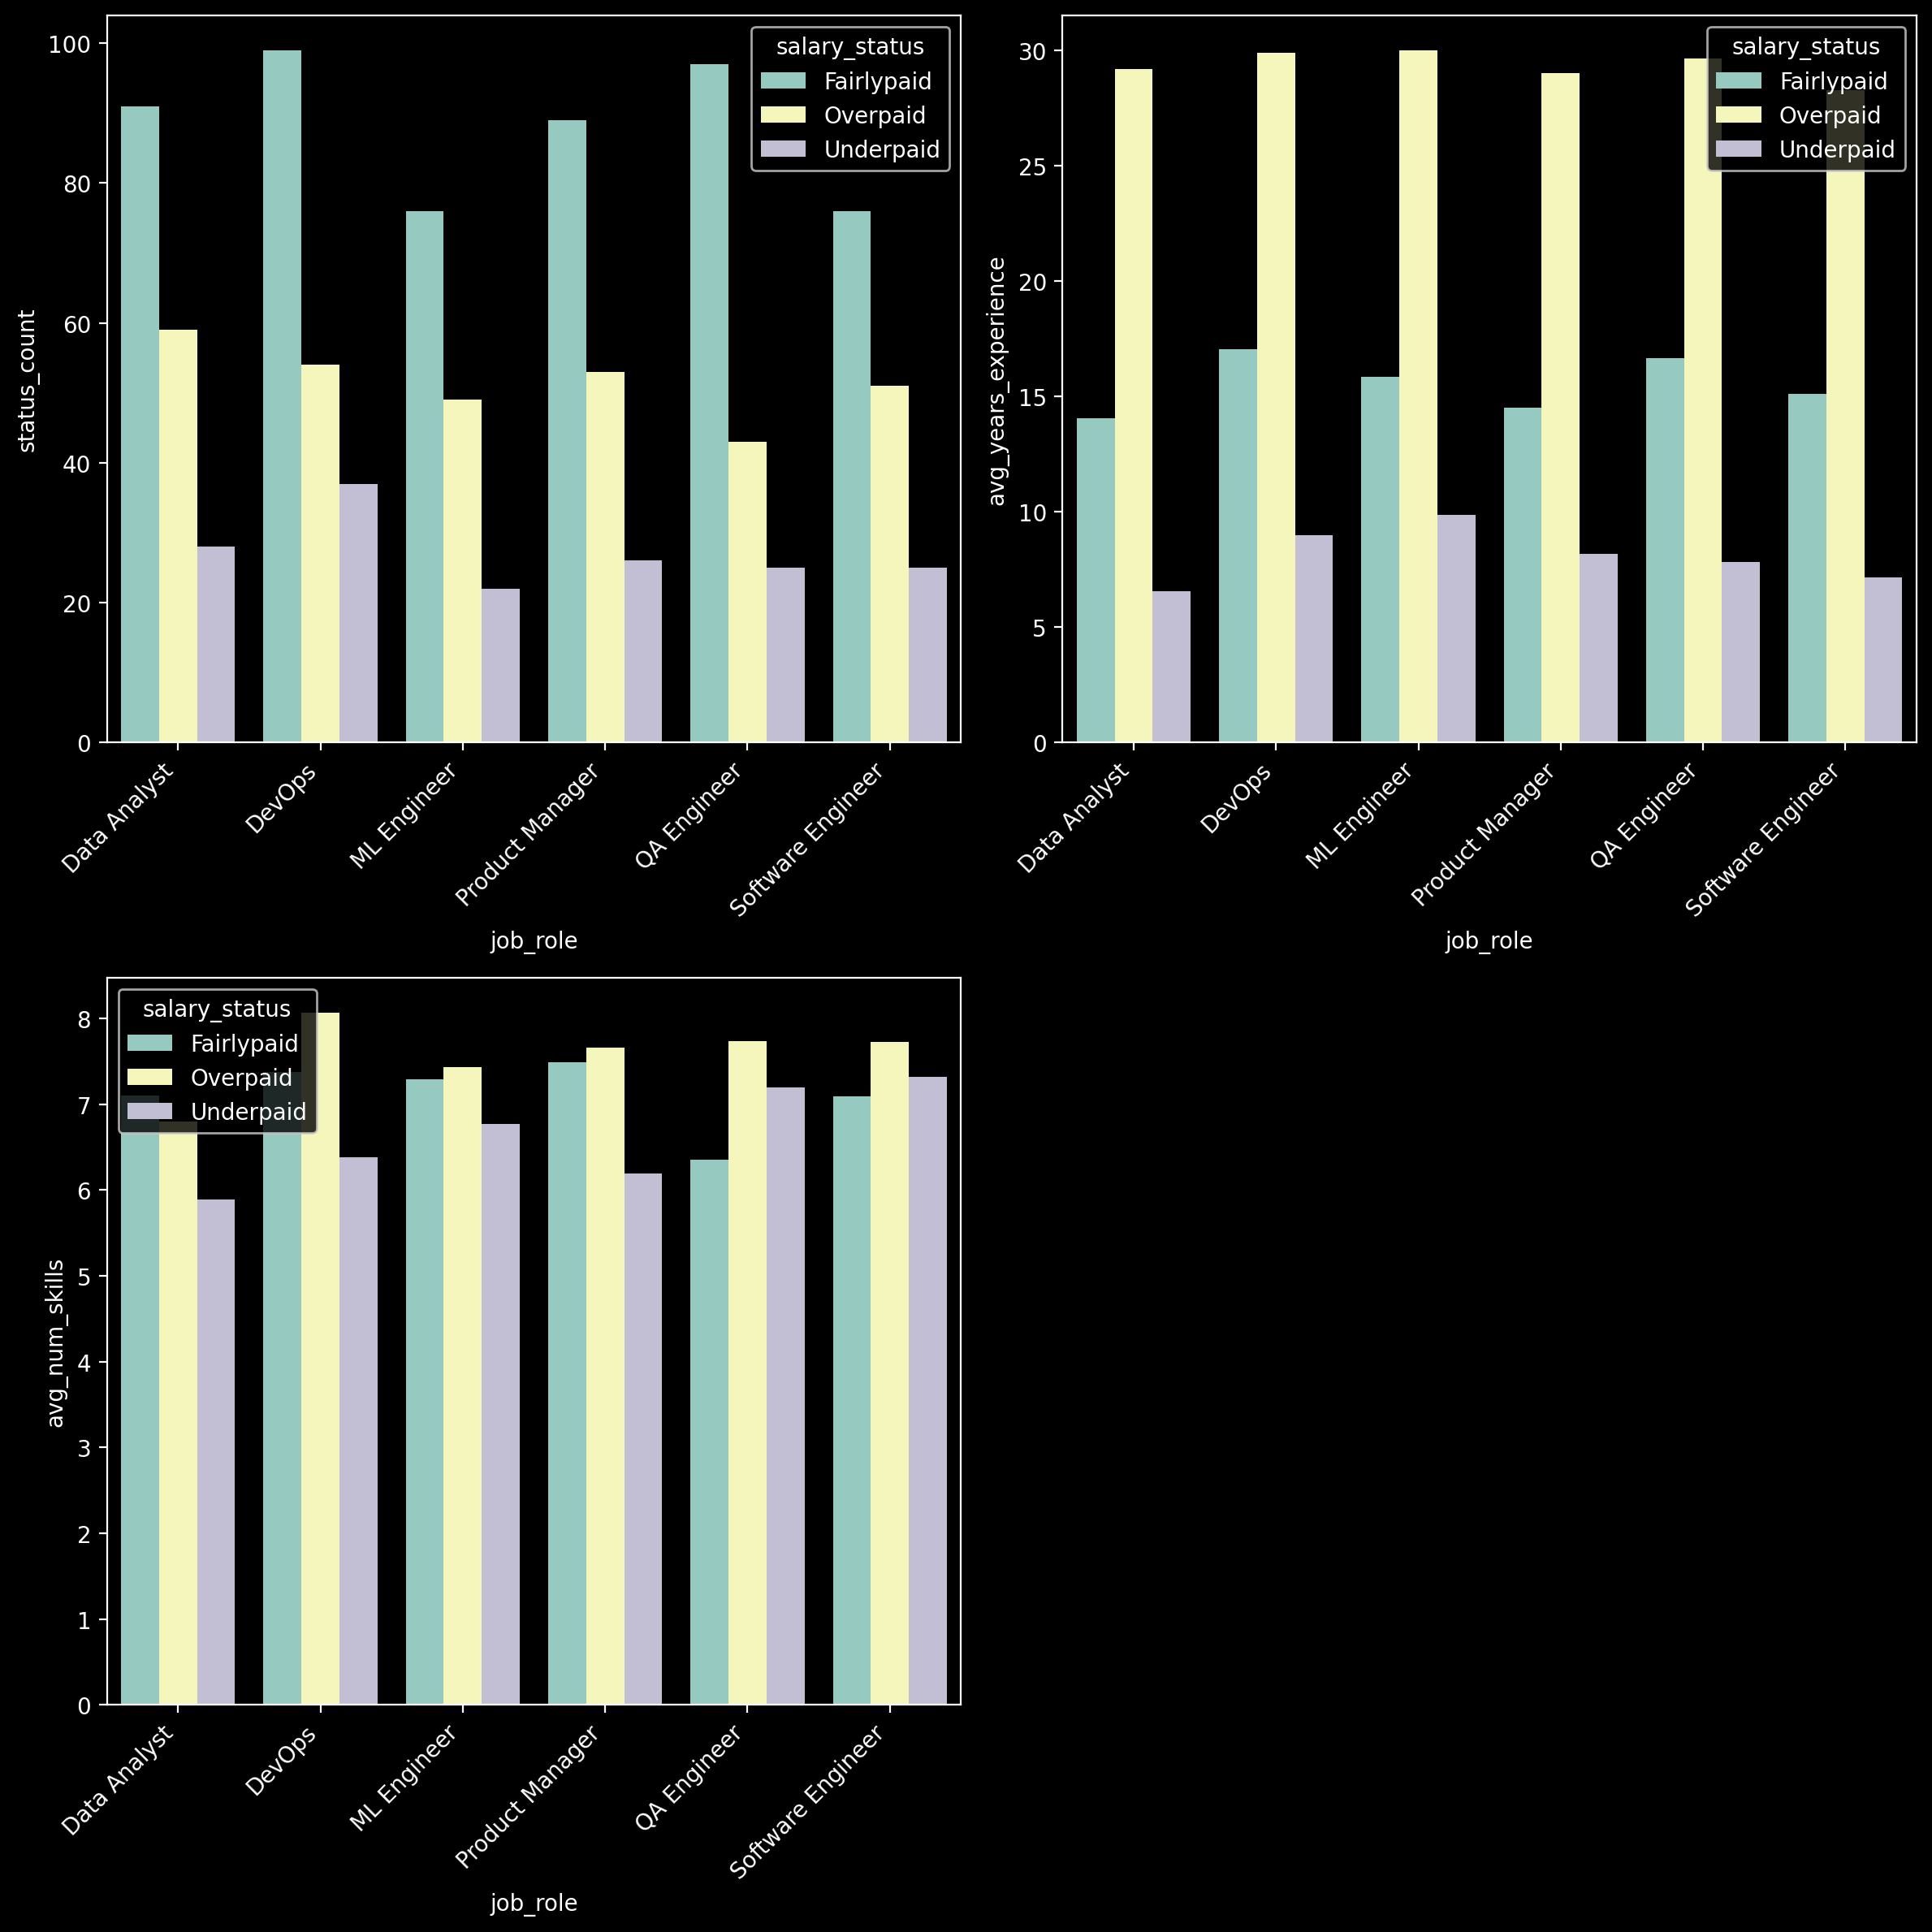

In [34]:

fig = plt.figure(figsize=(12,12), dpi=200, layout='tight')

plt.subplot(221)
sns.barplot(
    data=result, 
    x='job_role', 
    y='status_count', 
    hue='salary_status'
)
plt.xticks(rotation=45, ha='right')

plt.subplot(222)
sns.barplot(
    data=result, 
    x='job_role', 
    y='avg_years_experience', 
    hue='salary_status'
)
plt.xticks(rotation=45, ha='right');

plt.subplot(223)
sns.barplot(
    data=result, 
    x='job_role', 
    y='avg_num_skills', 
    hue='salary_status'
)


plt.xticks(rotation=45, ha='right')
plt.tight_layout();

In [35]:
salary_by_edu=round(df_staging.groupby('education_level', )['annual_salary_usd'].mean(). sort_values(ascending=False))
print('=== salary by edu ===')
print(salary_by_edu)

salary_by_exp = round(df_exp_bracket.groupby('years_experience')['annual_salary_usd'].mean().sort_values(ascending=False))
print('\n=== salary by years exp ===')
print(salary_by_exp)

salary_by_rmt = round(df_exp_bracket.groupby('remote_work')['annual_salary_usd'].mean().sort_values(ascending=False))
print('\n=== salary by remote work ===')
print(salary_by_rmt)

=== salary by edu ===
education_level
PhD            143086.0
Master         137630.0
Bachelor       136005.0
High School    132161.0
Name: annual_salary_usd, dtype: float64

=== salary by years exp ===
years_experience
Veteran      199818.0
Expert       180683.0
Senior       154310.0
Mid-Level    125897.0
Junior        96265.0
Name: annual_salary_usd, dtype: float64

=== salary by remote work ===
remote_work
1    139183.0
0    135496.0
Name: annual_salary_usd, dtype: float64


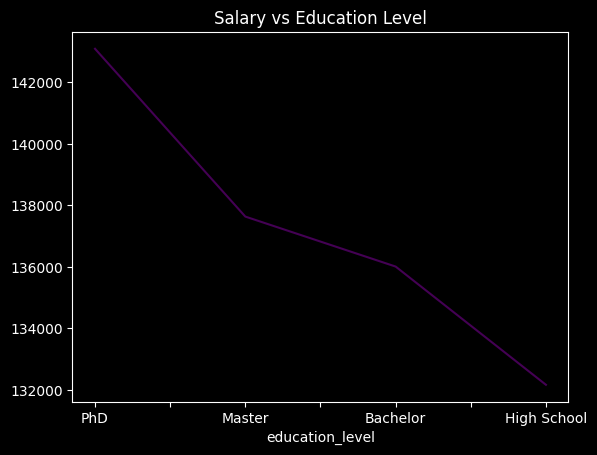

In [36]:
salary_by_edu.plot(kind='line', colormap='viridis')
plt.title('Salary vs Education Level');

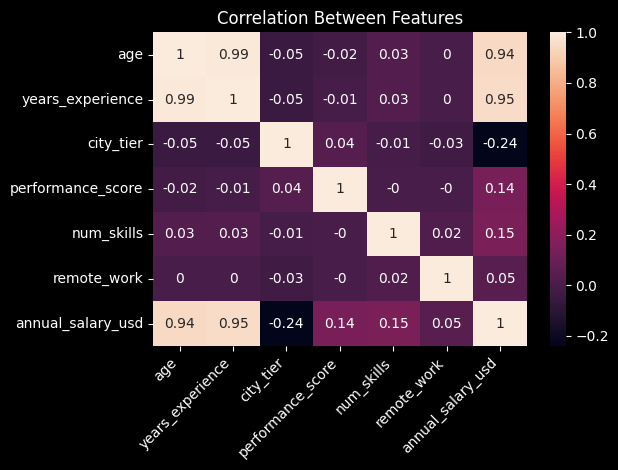

In [37]:
df_corr = round(df_staging.corr(numeric_only=True),2)
sns.heatmap(df_corr, annot=True )
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Between Features')
plt.tight_layout()
plt.savefig('correlation_features.png');

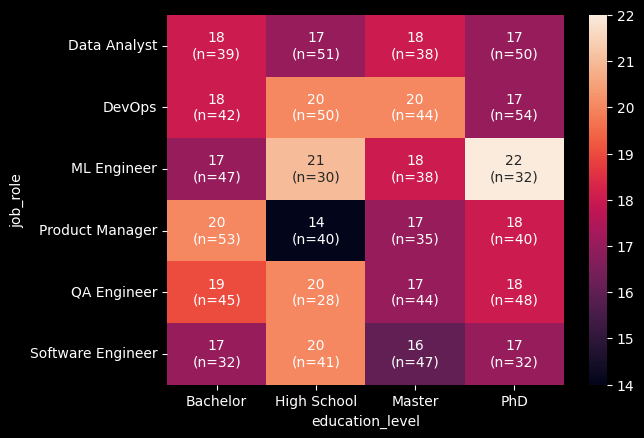

In [38]:
avg_experience=df_staging.pivot_table(
    index='job_role',
    columns='education_level',
    values='years_experience',
    aggfunc='mean'
    
)
avg_experience = avg_experience.astype(int)


total_employees=df_staging.pivot_table(
    index='job_role',
    columns='education_level',
    values='years_experience',
    aggfunc='count'
)



labels = (
    avg_experience.astype(str) + 
    "\n(n=" + 
    total_employees.astype(int).astype(str) + 
    ")"
)

sns.heatmap(avg_experience, annot=labels, fmt='s');

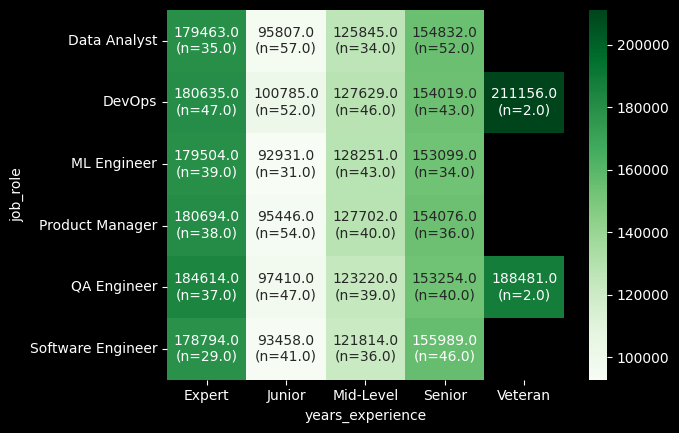

In [39]:
avg_salary=df_exp_skill_bracket.pivot_table(
    index='job_role',
    columns='years_experience',
    values='annual_salary_usd',
    aggfunc='mean'
    
)
avg_salary = round(avg_salary)


total_employees2=df_exp_skill_bracket.pivot_table(
    index='job_role',
    columns='years_experience',
    # values= tidak perlu ditulis jika pakai size, karena size menghitung baris secara utuh
    aggfunc='size'
)



labels2 = (
    avg_salary.astype(str) + 
    "\n(n=" + 
    total_employees2.astype(str) + 
    ")"
)

sns.heatmap(avg_salary, annot=labels2, fmt='s', cmap='Greens');

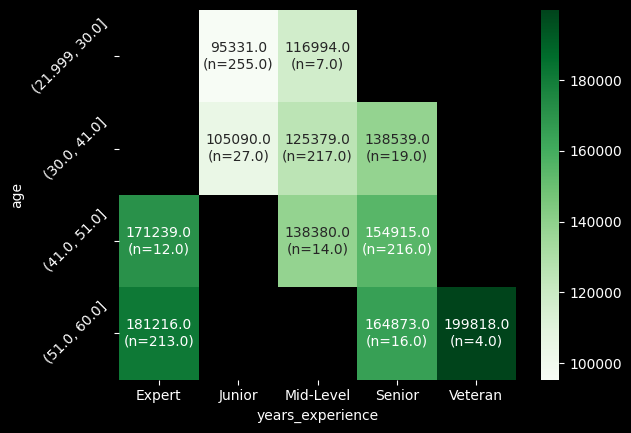

In [40]:
age_range = pd.qcut(df_exp_skill_bracket['age'], q=4)
avg_salary_age_exp=df_exp_skill_bracket.pivot_table(
    index= age_range,
    columns='years_experience',
    values='annual_salary_usd',
    aggfunc='mean'
    
)
avg_salary_age_exp = round(avg_salary_age_exp)


total_employees3=df_exp_skill_bracket.pivot_table(
    index= age_range,
    columns='years_experience',
    # values= tidak perlu ditulis jika pakai size, karena size menghitung baris secara utuh
    aggfunc='size'
)



labels3 = (
    avg_salary_age_exp.astype(str) + 
    "\n(n=" + 
    total_employees3.astype(str) + 
    ")"
)

sns.heatmap(avg_salary_age_exp, annot=labels3, fmt='s', cmap='Greens')
plt.yticks(rotation=45, ha='right');


In [41]:
df

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80
4,EMP0005,24,1,High School,DevOps,1,3.7,12,1,94126.86
...,...,...,...,...,...,...,...,...,...,...
995,EMP0996,37,13,Master,ML Engineer,2,3.4,11,0,127579.68
996,EMP0997,27,5,PhD,Product Manager,3,4.5,6,1,96672.53
997,EMP0998,33,10,Bachelor,Software Engineer,3,4.2,9,1,107247.32
998,EMP0999,33,9,High School,DevOps,3,4.8,5,0,100412.67


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder


# Basic correlations
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
print("--- Correlations with Salary ---")
print(corr_matrix['annual_salary_usd'].sort_values(ascending=False))

# Feature Importance using Random Forest
rf = RandomForestRegressor(random_state=42)
df_encoded = df.copy()
le = LabelEncoder()
for col in ['education_level', 'job_role']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop(['employee_id', 'annual_salary_usd'], axis=1)
y = df_encoded['annual_salary_usd']
rf.fit(X, y)

print("\n--- Feature Importances ---")
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

--- Correlations with Salary ---
annual_salary_usd    1.000000
years_experience     0.947786
age                  0.939521
num_skills           0.146429
performance_score    0.140946
remote_work          0.053142
city_tier           -0.240258
Name: annual_salary_usd, dtype: float64

--- Feature Importances ---
years_experience     0.840698
age                  0.068853
city_tier            0.033608
performance_score    0.029785
num_skills           0.013999
education_level      0.007674
job_role             0.003697
remote_work          0.001687
dtype: float64


In [43]:

X_lr = df_encoded.drop(['employee_id', 'annual_salary_usd'], axis=1)
X_lr = sm.add_constant(X_lr)
y_lr = df_encoded['annual_salary_usd']

model = sm.OLS(y_lr, X_lr).fit()
print(model.summary().tables[1])

raw_table = model.summary().tables[1].data
df_summary = pd.DataFrame(raw_table[1:], columns=raw_table[0])

df_summary.to_csv('tabel_statistik_gaji.csv', index=False)
print("Tabel berhasil diekspor menjadi CSV!")


print("\n--- Experience Salary Premium ---")
exp_groups = df.groupby(pd.qcut(df['years_experience'], q=4))['annual_salary_usd'].mean()
print(exp_groups)

print("\n--- Skill Premium ---")
print(df.groupby('num_skills')['annual_salary_usd'].mean())



                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              6.752e+04   2648.099     25.498      0.000    6.23e+04    7.27e+04
age                 -50.8201    109.706     -0.463      0.643    -266.102     164.462
years_experience   2842.9518    108.782     26.134      0.000    2629.482    3056.421
education_level    2460.3499    135.050     18.218      0.000    2195.333    2725.366
job_role            -25.4582     89.228     -0.285      0.775    -200.556     149.639
city_tier         -8098.0732    185.163    -43.735      0.000   -8461.430   -7734.717
performance_score  6219.3042    176.836     35.170      0.000    5872.288    6566.320
num_skills         1211.8626     49.188     24.637      0.000    1115.337    1308.388
remote_work        2805.9255    305.164      9.195      0.000    2207.084    3404.767
Tabel berhasil diekspor menjadi CSV!

--- Experience S

In [44]:
df_staging_rank = df_staging.copy()
df_staging_rank['rank']=df_staging_rank['annual_salary_usd'].rank(method='dense', ascending=False)
df_staging_rank = df_staging_rank.sort_values(by='rank')
df_staging_rank



,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,rank
16,EMP0017,60,38,PhD,Data Analyst,1,4.8,6,0,217067.54,1.0
30,EMP0031,60,40,Bachelor,DevOps,1,4.8,11,0,213998.04,2.0
61,EMP0062,59,39,PhD,DevOps,1,4.8,6,1,211753.19,3.0
590,EMP0591,58,37,PhD,QA Engineer,1,4.3,11,1,209754.42,4.0
522,EMP0523,58,36,PhD,QA Engineer,1,4.6,12,0,209740.24,5.0
...,...,...,...,...,...,...,...,...,...,...,...
935,EMP0936,23,2,High School,ML Engineer,2,2.0,2,0,70602.35,996.0
356,EMP0357,22,0,High School,Software Engineer,3,3.0,2,1,70503.74,997.0
963,EMP0964,22,0,High School,Data Analyst,2,2.1,3,0,69835.66,998.0
765,EMP0766,23,0,Bachelor,DevOps,2,2.3,2,0,67406.26,999.0


In [45]:
# INSIGHT
# pandas | numpy | statsmodel | scikitlearn |seaborn | matplotlib

# 1. Pengalaman adalah "Raja" Mutlak (84% berdasarkan rf): Lama pengalaman kerja (years_experience) adalah penentu gaji paling dominan, menyumbang 84% dari seluruh perbedaan gaji antar karyawan. Secara matematis, setiap tambahan 1 tahun pengalaman secara konsisten meningkatkan gaji sebesar ~$2.842 USD per tahun (bisa dilihat besaran coef yang telah dihitung oleh modul statsmodel).
# 2. Kinerja Dibayar Sangat Mahal (+$6.219/poin): Peningkatan 1 poin pada skor kinerja (misal dari 3.0 ke 4.0) secara presisi memberikan lonjakan gaji sebesar ~$6.219 USD. Ini adalah faktor pendorong kekayaan terbesar kedua yang bisa dikontrol langsung oleh karyawan.
# 3. Nilai Finansial dari Sebuah "Skill" Baru: Tidak perlu menebak-nebak nilai pengembangan diri. Menambah satu skill teknis baru ke dalam portofolio karyawan memiliki ekuivalensi yang sangat terukur, yakni ~$1.211 USD ekstra pada gaji tahunan dasar mereka.
# 4. Tidak Ada "Salary Compression": Hubungan linier yang kuat dan stabil antara pengalaman dan kompensasi (Junior ~$95k, Senior ~$154k, Veteran ~$181k) menunjukkan perusahaan sangat adil pada pegawai lama. Pegawai baru tidak dibayar melonjak melebihi pegawai senior. Loyalitas dan tenure sangat dihargai di sini, Sehingga anaslisa terhadap karyawan underpaid, overpaid dan fairlypaid sebelumya tidak relavan lagi.
# 5. Mitos Umur (Usia Sama Sekali Tidak Mempengaruhi Gaji): Analisis membuktikan bahwa variabel age secara statistik menggunakan statsmodel (bukan method .corr) tidak signifikan (p-value = 0.643). Karyawan yang lebih tua tidak dibayar lebih mahal karena senioritas usianya. Jika seorang berumur 40 tahun dan 25 tahun memiliki pengalaman kerja yang sama, gaji mereka identik. Tidak ada diskriminasi usia. 
# 6. Ilusi Role Pekerjaan (Job Title Tidak Relevan): Secara rata-rata kasar, "ML Engineer" atau "DevOps" seolah dibayar lebih mahal ($140k vs Software Engineer $135k). Namun regresi membuktikan ini ilusi optik akibat bias pengalaman. ML Engineer di dataset ini kebetulan rata-rata punya masa kerja lebih lama. Jika pengalaman disetarakan, Job Title tidak memberikan perbedaan dampak gaji yang signifikan (p-value = 0.775).
# 9. Lulusan SMA Bisa Mengalahkan Gaji Gelar PhD: Karena 1 tahun pengalaman bernilai ~$2.842 dan latar belakang pendidikan hanya menyumbang <1% varians gaji, seorang lulusan SMA yang langsung bekerja dan memiliki 4 tahun tabungan pengalaman akan secara statistik mengalahkan gaji awal pemegang gelar PhD.
# 10. ROI Pendidikan Master (S2) Relatif Negatif: Rata-rata lompatan gaji dasar dari pemegang gelar S1/Bachelor ($136.004) ke S2/Master ($137.630) sangat tipis, hanya ~$1.626 USD. Jika menempuh S2 mengharuskan seseorang jeda kerja 2 tahun (kehilangan gaji dan pengalaman senilai lebih dari $5.600+ ke depannya), secara finansial gelar S2 di perusahaan ini merugikan.
# 11. Kinerja > Kredensial Akademik: Meningkatkan skor kinerja sebesar 1.5 poin (bernilai ~$9.300) akan memberikan kenaikan gaji yang jauh lebih besar daripada seseorang yang menghabiskan bertahun-tahun mengupgrade pendidikan dari Bachelor ke PhD (selisih rata-rata hanya ~$7.000). Usaha/effort jauh mengalahkan kredensial.
# 12. Fokus pada "Kedalaman Kinerja" vs "Keluasan Skill": Untuk mendapat kenaikan $6.000 USD, karyawan bisa mengorbankan ratusan jam belajar 5 skill baru ($1.211 x 5) ATAU sekadar memperbaiki skor performa saat ini sebesar 1 poin. Memperbaiki output kerja (kinerja) adalah jalan pintas finansial yang lebih efisien daripada mengoleksi sertifikasi/skill.
# 13. Penalti Geografis yang Masif (City Tier): Lokasi memiliki dampak pinalti finansial yang kejam. Turun satu tingkat kota (misal dari pindah dari Tier 1 ke Tier 2) akan memberikan "penalti" atau pemotongan standar gaji sebesar ~$8.098 USD per tahun. Dari Tier 1 ke Tier 3 berarti kehilangan ~$16.000 USD.
# 14. "Premi" Kerja Remote (Remote Work Premium): Bertentangan dengan tren tech-winter saat ini di mana perusahaan memotong gaji pekerja remote, perusahaan dalam dataset ini menerapkan Premi Remote. Pekerja remote dibayar ~$2.805 USD lebih tinggi dibanding pekerja on-site dengan kualifikasi identik.
# 15. Arbitrase Finansial (Lokasi vs Remote): Mengingat kota Tier 3 memotong gaji hingga $16.000, pekerja di kota Tier 3 harus berupaya mutlak mendapatkan kontrak kerja berstatus "Remote" untuk menciptakan arbitrage. Mereka bisa menikmati biaya hidup rendah di Tier 3 sekaligus mendapatkan suntikan premi remote +$2.805.
# 15. Bias "Cost of Living" vs "Value-Based Pay": Fakta bahwa city_tier adalah faktor terbesar kedua setelah pengalaman (berdasarkan rank feature importance, city tier menyumbang 3,3% deviasi gaji ) menunjukkan perusahaan masih menghitung gaji berdasarkan "Biaya Hidup Karyawan" (Cost of Living), bukan murni dari seberapa besar value yang diberikan karyawan untuk perusahaan.
# 16."The Golden Triangle" untuk Kompensasi Puncak: Karyawan top 1% dengan gaji raksasa di perusahaan ini adalah mereka yang berhasil menyatukan tiga pilar secara berbarengan: Berada di kota Tier 1, memiliki Masa Kerja Belasan Tahun, dan Skor Kinerja konsisten di atas 4.5. Kurang satu pilar saja, kompensasi jatuh secara signifikan.
# 17. "Hack" Karier Paling Optimal (The Ultimate Employee Roadmap): Rute karier paling kaya dan menguntungkan secara matematis di perusahaan ini adalah: (1) Mulailah bekerja sedini mungkin setelah S1 (skip S2 untuk menumpuk multiplier pengalaman bernilai $2.8k/tahun), (2) Negosiasikan status "Remote" (+2.8k), (3) Menetap di kota Tier 1 (+8k), dan (4) Berhenti membuang waktu mengoleksi banyak skill dasar (+1.2k), alihkan 100% fokus Anda pada KPI performa utama perusahaan (+6.2k per poin).
# TERIMA KASIH 